# Classical and Neural Longstaff–Schwartz for American Put Options

## Learning continuation values from simulated risk-neutral paths

**SoftUni Deep Learning Final Project**  
**Author:** Kamen Dimitrov  
**Notebook:** `07_neural_longstaff_schwartz.ipynb`

---

The earlier notebooks learn a static American-option pricing surface from CRR-generated labels. This notebook studies a different deep-learning application: the neural network participates directly in the optimal-stopping algorithm by estimating continuation values from simulated paths.

The experiment compares:

1. a high-resolution Cox–Ross–Rubinstein tree;
2. classical Least-Squares Monte Carlo with polynomial or Laguerre basis functions;
3. an amortized neural Least-Squares Monte Carlo policy.

The stopping policy is always fitted on one set of paths and valued on an independent set. This separation is necessary because evaluating a policy on the paths used to estimate it produces an optimistic result.

## 1. Research objective

Longstaff and Schwartz (2001) introduced a practical regression-based Monte Carlo method for American options. At each exercise date, discounted future cash flows are regressed on functions of the current state. The estimated continuation value is then compared with intrinsic value.

The central question is:

> At a matched simulation budget, can neural continuation-value regression estimate American put prices and exercise policies more accurately than classical polynomial Longstaff–Schwartz?

This experiment complements the static neural surrogates developed in Notebooks 04–06. It does not replace them. The static models are expected to remain substantially faster for repeated inference after training, while neural LSM provides a more direct solution to the stopping problem.

## 2. Risk-neutral simulation

Under risk-neutral geometric Brownian motion,

$$
S_{t+\Delta t}
=
S_t\exp\left[
\left(r-q-\frac{1}{2}\sigma^2\right)\Delta t
+
\sigma\sqrt{\Delta t}Z
\right].
$$

The simulator uses fixed seeds and antithetic variates. Antithetic sampling reduces variance by pairing every normal shock sequence with its negative. The theoretical model is unchanged.

## 3. Execution profiles

The full experiment is computationally material. Three explicit profiles are supplied:

- **smoke** — verifies the full workflow locally;
- **standard** — produces intermediate research results;
- **final** — uses the approved contract and simulation budgets.

The final profile uses 200 training contracts, 50 validation contracts, 100 held-out contracts, 40 out-of-domain contracts, 25 exercise dates, 25,000 policy-training paths per contract, and 50,000 independent valuation paths per contract.

In [1]:
from pathlib import Path
from dataclasses import asdict
import json
import os
import sys
import time
from tqdm import tqdm

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torchinfo import summary

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.evaluation.lsm_comparison import (
    aggregate_seed_results,
    compare_lsm_methods,
    confidence_interval_coverage,
    exercise_policy_metrics,
    runtime_summary,
    stopping_time_total_variation,
)
from src.pricing.binomial_tree import crr_option_price
from src.pricing.longstaff_schwartz import longstaff_schwartz_put_price
from src.pricing.simulation import (
    GBMContract,
    sample_contracts_latin_hypercube,
    simulate_contract_paths,
    validate_simulated_moments,
)
from src.training.lsm_training import (
    NeuralLSMTrainingConfig,
    evaluate_neural_lsm_policy,
    fit_neural_lsm_policy,
)

from src.models.neural_longstaff_schwartz import (
    ContinuationNetworkConfig,
    ContinuationValueNetwork,
    ContractPathBatch,
    NeuralLSMPolicy,
)

ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "neural_lsm"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
CONFIG_PATH = PROJECT_ROOT / "data" / "manifests" / "lsm_experiment_config.json"

print(f"Project root: {PROJECT_ROOT}")
print(f"Torch device available: {'cuda' if torch.cuda.is_available() else 'cpu'}")

def inspect_training_artifacts(
    manifest_path,
    required_paths,
    *,
    expected_notebook,
    expected_profile,
):
    """Return whether a complete, compatible training package is available."""
    missing = [
        path
        for path in required_paths
        if not path.is_file() or path.stat().st_size == 0
    ]
    if missing:
        return False, "missing: " + ", ".join(path.name for path in missing)

    if not manifest_path.is_file():
        return False, f"missing: {manifest_path.name}"

    try:
        manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    except (OSError, json.JSONDecodeError) as exc:
        return False, f"invalid manifest: {exc}"

    if manifest.get("status") != "complete":
        return False, "manifest status is not complete"
    if manifest.get("notebook") != expected_notebook:
        return False, "manifest belongs to another notebook"
    if manifest.get("training_profile") != expected_profile:
        return False, "training profile does not match"

    return True, "complete compatible package found"


def write_training_manifest(path, payload):
    """Write the completion marker last and atomically."""
    temporary = path.with_name(path.name + ".tmp")
    temporary.write_text(
        json.dumps(payload, indent=2),
        encoding="utf-8",
    )
    temporary.replace(path)


Project root: /storage/deep_learning_american_option_pricing
Torch device available: cuda


In [2]:

with CONFIG_PATH.open("r", encoding="utf-8") as file:
    experiment_design = json.load(file)

os.environ["LSM_PROFILE"] = "final"
PROFILE = os.getenv(
    "LSM_PROFILE",
    experiment_design["default_profile"],
)
if PROFILE not in experiment_design["profiles"]:
    raise ValueError(f"Unknown LSM profile: {PROFILE}")

FORCE_TRAIN = False
TRAINING_PROFILE = PROFILE
profile = experiment_design["profiles"][PROFILE]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = int(experiment_design["seeds"][0])

POLICY_PATH = ARTIFACT_DIR / "neural_lsm_policy.pt"
HISTORY_PARQUET_PATH = ARTIFACT_DIR / "training_history.parquet"
HISTORY_CSV_PATH = ARTIFACT_DIR / "training_history.csv"
TRAINING_CONFIG_PATH = ARTIFACT_DIR / "training_config.json"
TRAINING_MANIFEST_PATH = ARTIFACT_DIR / "training_complete.json"

pd.Series(profile, name=PROFILE).to_frame()


,final
training_contracts,200
validation_contracts,50
test_contracts,100
ood_contracts,40
exercise_steps,25
policy_training_paths_per_contract,25000
valuation_paths_per_contract,50000
neural_epochs_per_step,50
max_training_samples_per_step,250000


## 4. Representative contract and simulation diagnostics

The first calculation validates the simulator independently of the stopping algorithm. The empirical terminal mean and variance should be close to their theoretical risk-neutral values. This check helps distinguish simulation errors from continuation-regression errors later in the notebook.

In [3]:
representative_contract = GBMContract(
    contract_id="representative",
    spot=90.0,
    strike=100.0,
    time_to_maturity=1.0,
    risk_free_rate=0.05,
    dividend_yield=0.01,
    volatility=0.20,
)

representative_paths = simulate_contract_paths(
    representative_contract,
    n_paths=max(20_000, profile["valuation_paths_per_contract"]),
    n_steps=profile["exercise_steps"],
    seed=SEED,
)

moment_validation = validate_simulated_moments(
    representative_paths,
    representative_contract,
)
pd.Series(moment_validation.to_dict(), name="Value").to_frame()

,Value
empirical_mean,93.663642
theoretical_mean,93.672970
mean_relative_error,0.000100
empirical_variance,356.165866
theoretical_variance,358.099250
variance_relative_error,0.005399
n_paths,50000.000000


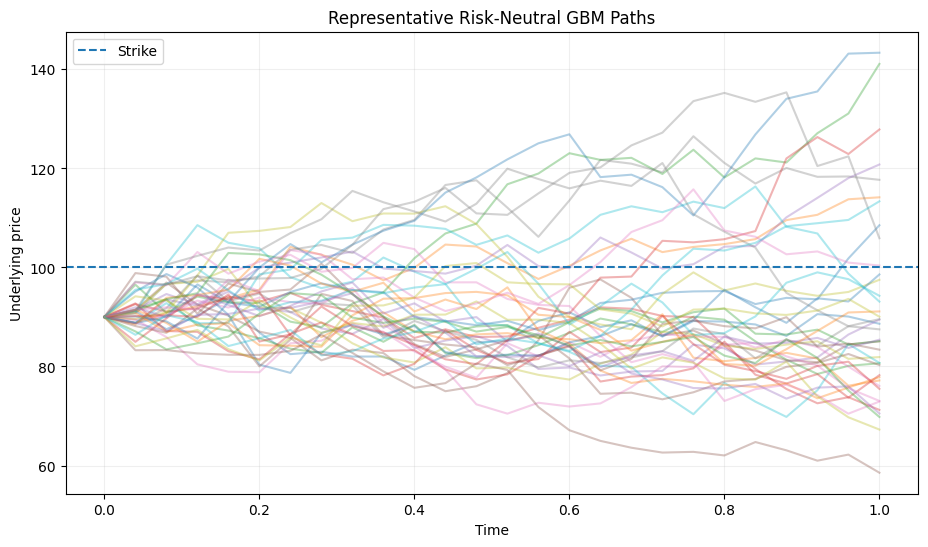

In [4]:
plt.figure(figsize=(11, 6))
time_grid = np.linspace(
    0.0,
    representative_contract.time_to_maturity,
    profile["exercise_steps"] + 1,
)
for path in representative_paths[:40]:
    plt.plot(time_grid, path, alpha=0.35)
plt.axhline(representative_contract.strike, linestyle="--", label="Strike")
plt.xlabel("Time")
plt.ylabel("Underlying price")
plt.title("Representative Risk-Neutral GBM Paths")
plt.legend()
plt.grid(alpha=0.20)
plt.show()

The path chart is descriptive rather than evidential. The terminal-moment diagnostics provide the actual numerical validation. The stopping policy is examined only after the simulated process behaves consistently with its theoretical specification.

## 5. Classical Longstaff–Schwartz benchmark

Classical LSM regresses discounted future cash flows on basis functions of normalized spot. Three predefined specifications are compared:

- degree-2 polynomial;
- degree-3 polynomial;
- degree-3 weighted Laguerre basis.

The specification is selected on validation evidence rather than the final held-out contracts.

In [5]:
training_paths = simulate_contract_paths(
    representative_contract,
    n_paths=profile["policy_training_paths_per_contract"],
    n_steps=profile["exercise_steps"],
    seed=SEED + 1,
)
valuation_paths = simulate_contract_paths(
    representative_contract,
    n_paths=profile["valuation_paths_per_contract"],
    n_steps=profile["exercise_steps"],
    seed=SEED + 2,
)

crr_representative = crr_option_price(
    spot=representative_contract.spot,
    strike=representative_contract.strike,
    time_to_maturity=representative_contract.time_to_maturity,
    risk_free_rate=representative_contract.risk_free_rate,
    dividend_yield=representative_contract.dividend_yield,
    volatility=representative_contract.volatility,
    steps=experiment_design["crr_benchmark_steps"],
    option_type="put",
    exercise_style="american",
)

basis_rows = []
basis_experiments = {}
for candidate in experiment_design["classical_basis_candidates"]:
    started = time.perf_counter()
    result = longstaff_schwartz_put_price(
        training_paths,
        valuation_paths,
        strike=representative_contract.strike,
        time_to_maturity=representative_contract.time_to_maturity,
        risk_free_rate=representative_contract.risk_free_rate,
        basis=candidate["basis"],
        degree=candidate["degree"],
    )
    runtime = time.perf_counter() - started
    name = f"{candidate['basis']}_degree_{candidate['degree']}"
    basis_experiments[name] = result
    basis_rows.append(
        {
            "specification": name,
            "price": result.valuation.price,
            "standard_error": result.valuation.standard_error,
            "ci_low": result.valuation.confidence_interval_low,
            "ci_high": result.valuation.confidence_interval_high,
            "absolute_error_vs_crr": abs(result.valuation.price - crr_representative),
            "early_exercise_rate": result.valuation.exercised_early_rate,
            "runtime_seconds": runtime,
        }
    )

basis_results = pd.DataFrame(basis_rows).sort_values("absolute_error_vs_crr")
basis_results

,specification,price,standard_error,ci_low,ci_high,absolute_error_vs_crr,early_exercise_rate,runtime_seconds
2,laguerre_degree_3,11.697828,0.037175,11.624966,11.770689,0.064383,0.65180,0.081448
1,polynomial_degree_3,11.694501,0.037246,11.621501,11.767502,0.067709,0.65304,0.064061
0,polynomial_degree_2,11.694332,0.037148,11.621523,11.767141,0.067879,0.62480,0.064882


In [6]:
BEST_CLASSICAL_SPECIFICATION = basis_results.iloc[0]["specification"]
best_classical = basis_experiments[BEST_CLASSICAL_SPECIFICATION]
BEST_CLASSICAL_BASIS = best_classical.policy.basis
BEST_CLASSICAL_DEGREE = best_classical.policy.degree

print(f"CRR benchmark: {crr_representative:.6f}")
print(f"Selected classical specification: {BEST_CLASSICAL_SPECIFICATION}")

CRR benchmark: 11.762210
Selected classical specification: laguerre_degree_3


The selected basis is not assumed to be universally optimal. Basis risk is an inherent limitation of classical LSM. A specification that performs well for one contract may perform differently across other parts of the pricing domain.

## 6. Path-count convergence

Monte Carlo estimates must be reported together with sampling uncertainty. The next experiment varies the path budget while keeping training and valuation samples independent.

In [7]:
path_counts = [2_000, 5_000, 10_000]
if PROFILE != "smoke":
    path_counts.extend([25_000, 50_000])

path_convergence_rows = []
for count in path_counts:
    train_sample = simulate_contract_paths(
        representative_contract,
        n_paths=count,
        n_steps=profile["exercise_steps"],
        seed=SEED + 100 + count,
    )
    valuation_sample = simulate_contract_paths(
        representative_contract,
        n_paths=2 * count,
        n_steps=profile["exercise_steps"],
        seed=SEED + 200 + count,
    )
    started = time.perf_counter()
    experiment = longstaff_schwartz_put_price(
        train_sample,
        valuation_sample,
        strike=representative_contract.strike,
        time_to_maturity=representative_contract.time_to_maturity,
        risk_free_rate=representative_contract.risk_free_rate,
        basis=BEST_CLASSICAL_BASIS,
        degree=BEST_CLASSICAL_DEGREE,
    )
    path_convergence_rows.append(
        {
            "policy_paths": count,
            "valuation_paths": 2 * count,
            "price": experiment.valuation.price,
            "standard_error": experiment.valuation.standard_error,
            "ci_low": experiment.valuation.confidence_interval_low,
            "ci_high": experiment.valuation.confidence_interval_high,
            "absolute_error_vs_crr": abs(
                experiment.valuation.price - crr_representative
            ),
            "runtime_seconds": time.perf_counter() - started,
        }
    )

path_convergence = pd.DataFrame(path_convergence_rows)
path_convergence

,policy_paths,valuation_paths,price,standard_error,ci_low,ci_high,absolute_error_vs_crr,runtime_seconds
0,2000,4000,11.574564,0.128806,11.322109,11.827019,0.187646,0.013383
1,5000,10000,11.684843,0.083333,11.521513,11.848172,0.077368,0.022029
2,10000,20000,11.661670,0.058723,11.546574,11.776765,0.100541,0.036424
3,25000,50000,11.753932,0.037261,11.680902,11.826961,0.008279,0.084606
4,50000,100000,11.739670,0.026561,11.687611,11.791730,0.022540,0.168336


## 7. Exercise-date convergence

The American contract allows continuous exercise, while LSM evaluates a discrete set of exercise dates. Increasing the number of dates reduces discretization error but increases regression complexity and runtime.

In [8]:
exercise_step_grid = [10, 25, 50]
if PROFILE == "smoke":
    exercise_step_grid = [5, 10, 20]

exercise_date_rows = []
for n_steps in exercise_step_grid:
    train_sample = simulate_contract_paths(
        representative_contract,
        n_paths=profile["policy_training_paths_per_contract"],
        n_steps=n_steps,
        seed=SEED + 300 + n_steps,
    )
    valuation_sample = simulate_contract_paths(
        representative_contract,
        n_paths=profile["valuation_paths_per_contract"],
        n_steps=n_steps,
        seed=SEED + 400 + n_steps,
    )
    started = time.perf_counter()
    experiment = longstaff_schwartz_put_price(
        train_sample,
        valuation_sample,
        strike=representative_contract.strike,
        time_to_maturity=representative_contract.time_to_maturity,
        risk_free_rate=representative_contract.risk_free_rate,
        basis=BEST_CLASSICAL_BASIS,
        degree=BEST_CLASSICAL_DEGREE,
    )
    exercise_date_rows.append(
        {
            "exercise_steps": n_steps,
            "price": experiment.valuation.price,
            "standard_error": experiment.valuation.standard_error,
            "absolute_error_vs_crr": abs(
                experiment.valuation.price - crr_representative
            ),
            "runtime_seconds": time.perf_counter() - started,
        }
    )

exercise_date_convergence = pd.DataFrame(exercise_date_rows)
exercise_date_convergence

,exercise_steps,price,standard_error,absolute_error_vs_crr,runtime_seconds
0,10,11.699089,0.037027,0.063121,0.032925
1,25,11.705779,0.035963,0.056432,0.082962
2,50,11.725162,0.035564,0.037049,0.164110


## 8. Contract-level research design

The neural policy is amortized across a domain of contracts. One continuation network is trained for each exercise-time index, while contract parameters enter the network as features. Test-contract identifiers are excluded from both network fitting and validation.

The neural input vector is

$$
\left[
\log(S/K),\;
T-t,\;
r,\;
q,\;
\sigma
\right].
$$

The target is the discounted future cash flow normalized by strike.

In [9]:
in_domain_ranges = {
    key: tuple(value)
    for key, value in experiment_design["in_domain_ranges"].items()
}

training_contracts = sample_contracts_latin_hypercube(
    n_contracts=profile["training_contracts"],
    parameter_ranges=in_domain_ranges,
    seed=SEED + 500,
    prefix="train",
)
validation_contracts = sample_contracts_latin_hypercube(
    n_contracts=profile["validation_contracts"],
    parameter_ranges=in_domain_ranges,
    seed=SEED + 600,
    prefix="validation",
)
test_contracts = sample_contracts_latin_hypercube(
    n_contracts=profile["test_contracts"],
    parameter_ranges=in_domain_ranges,
    seed=SEED + 700,
    prefix="test",
)

contract_grid = pd.DataFrame(
    [
        {**contract.to_dict(), "sample": sample}
        for sample, contracts in [
            ("training", training_contracts),
            ("validation", validation_contracts),
            ("test", test_contracts),
        ]
        for contract in contracts
    ]
)
contract_grid.groupby("sample").size().to_frame("contracts")

,contracts
sample,
test,100
training,200
validation,50


In [10]:

network_config = ContinuationNetworkConfig(
    input_dim=5,
    hidden_dims=(64, 64, 32),
    dropout=0.0,
)

representative_continuation_network = ContinuationValueNetwork(
    network_config
).to(DEVICE)

summary(
    representative_continuation_network,
    input_size=(1, network_config.input_dim),
    device=DEVICE,
    col_names=("input_size", "output_size", "num_params", "trainable"),
)


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
ContinuationValueNetwork                 [1, 5]                    [1]                       --                        True
├─Sequential: 1-1                        [1, 5]                    [1, 1]                    --                        True
│    └─Linear: 2-1                       [1, 5]                    [1, 64]                   384                       True
│    └─SiLU: 2-2                         [1, 64]                   [1, 64]                   --                        --
│    └─Linear: 2-3                       [1, 64]                   [1, 64]                   4,160                     True
│    └─SiLU: 2-4                         [1, 64]                   [1, 64]                   --                        --
│    └─Linear: 2-5                       [1, 64]                   [1, 32]                   2,080                     True
│    └─

In [11]:

def build_path_batches(
    contracts,
    *,
    n_paths,
    n_steps,
    seed_offset,
    description,
):
    batches = []

    progress = tqdm(
        enumerate(contracts),
        total=len(contracts),
        desc=description,
        unit="contract",
    )

    for index, contract in progress:
        paths = simulate_contract_paths(
            contract,
            n_paths=n_paths,
            n_steps=n_steps,
            seed=SEED + seed_offset + index,
        )
        batches.append(
            ContractPathBatch(
                contract=contract,
                paths=paths,
            )
        )

    return batches


existing_history_path = (
    HISTORY_PARQUET_PATH
    if HISTORY_PARQUET_PATH.is_file()
    else HISTORY_CSV_PATH
)
training_outputs_available, availability_reason = inspect_training_artifacts(
    TRAINING_MANIFEST_PATH,
    [
        POLICY_PATH,
        existing_history_path,
        TRAINING_CONFIG_PATH,
    ],
    expected_notebook="07_neural_longstaff_schwartz",
    expected_profile=TRAINING_PROFILE,
)
RUN_NEURAL_TRAINING = (
    FORCE_TRAIN or not training_outputs_available
)

print(f"Force training:             {FORCE_TRAIN}")
print(f"Training outputs available: {training_outputs_available}")
print(
    "Decision:                   "
    f"{'train' if RUN_NEURAL_TRAINING else 'load'}"
)
print(f"Artifact check:             {availability_reason}")

if RUN_NEURAL_TRAINING:
    TRAINING_MANIFEST_PATH.unlink(missing_ok=True)
    training_batches = build_path_batches(
        training_contracts,
        n_paths=profile[
            "policy_training_paths_per_contract"
        ],
        n_steps=profile["exercise_steps"],
        seed_offset=1_000,
        description="Training path generation",
    )

    validation_batches = build_path_batches(
        validation_contracts,
        n_paths=profile[
            "policy_training_paths_per_contract"
        ],
        n_steps=profile["exercise_steps"],
        seed_offset=2_000,
        description="Validation path generation",
    )
else:
    training_batches = []
    validation_batches = []
    print(
        "Saved neural LSM policy found. "
        "Training and validation path generation skipped."
    )


Force training:             True
Training outputs available: False
Decision:                   train
Artifact check:             missing: training_config.json


Validation path generation: 100%|██████████| 50/50 [00:00<00:00, 66.55contract/s]


## 9. Neural continuation-policy training

The continuation network uses a non-negative `Softplus` output. This is economically appropriate because continuation value cannot be negative. Networks are trained backward from the latest exercise date, and the next earlier network may warm-start from the later network's weights.

The neural policy is evaluated only on independent paths from contracts excluded from policy training.

**Execution control.** `FORCE_TRAIN = True` runs the full training stage and rebuilds its artifacts. After one successful run, set it to `False`; the notebook then loads the saved checkpoint and training history when the completion manifest and all required files are present. Missing or incompatible artifacts automatically trigger training.


In [12]:

training_config = NeuralLSMTrainingConfig(
    network=network_config,
    epochs=profile["neural_epochs_per_step"],
    batch_size=1024,
    learning_rate=1e-3,
    weight_decay=1e-5,
    patience=max(
        3,
        min(
            8,
            profile["neural_epochs_per_step"] // 3,
        ),
    ),
    minimum_samples_per_step=64,
    maximum_samples_per_step=profile[
        "max_training_samples_per_step"
    ],
    warm_start_from_later_step=True,
    seed=SEED,
    device=DEVICE,
)

if RUN_NEURAL_TRAINING:
    neural_training_started = time.perf_counter()
    neural_policy, neural_training_history = (
        fit_neural_lsm_policy(
            training_batches,
            validation_batches,
            config=training_config,
        )
    )
    neural_training_runtime = (
        time.perf_counter() - neural_training_started
    )

    neural_policy.save(POLICY_PATH)
    try:
        neural_training_history.to_parquet(
            HISTORY_PARQUET_PATH,
            index=False,
        )
        saved_history_path = HISTORY_PARQUET_PATH
        if HISTORY_CSV_PATH.exists():
            HISTORY_CSV_PATH.unlink()
    except ImportError:
        neural_training_history.to_csv(
            HISTORY_CSV_PATH,
            index=False,
        )
        saved_history_path = HISTORY_CSV_PATH

    TRAINING_CONFIG_PATH.write_text(
        json.dumps(asdict(training_config), indent=2),
        encoding="utf-8",
    )

    maximum_epoch = (
        int(neural_training_history["epoch"].max())
        if not neural_training_history.empty
        else 0
    )
    write_training_manifest(
        TRAINING_MANIFEST_PATH,
        {
            "status": "complete",
            "notebook": "07_neural_longstaff_schwartz",
            "training_profile": TRAINING_PROFILE,
            "requested_epochs_per_step": int(
                training_config.epochs
            ),
            "maximum_epochs_completed_per_step": (
                maximum_epoch
            ),
            "trained_continuation_steps": len(
                neural_policy.steps
            ),
            "training_runtime_seconds": float(
                neural_training_runtime
            ),
            "checkpoint": POLICY_PATH.name,
            "history": saved_history_path.name,
        },
    )
else:
    neural_policy = NeuralLSMPolicy.load(
        POLICY_PATH,
        map_location=DEVICE,
    )
    if HISTORY_PARQUET_PATH.is_file():
        neural_training_history = pd.read_parquet(
            HISTORY_PARQUET_PATH
        )
    else:
        neural_training_history = pd.read_csv(
            HISTORY_CSV_PATH
        )

    training_manifest = json.loads(
        TRAINING_MANIFEST_PATH.read_text(
            encoding="utf-8"
        )
    )
    neural_training_runtime = float(
        training_manifest.get(
            "training_runtime_seconds",
            float("nan"),
        )
    )

print(
    f"Continuation networks available: "
    f"{len(neural_policy.steps)}"
)
print(
    f"Recorded training runtime: "
    f"{neural_training_runtime:.2f} seconds"
)
neural_training_history.tail()


Starting neural Longstaff-Schwartz training
Device: cuda
Training contracts: 200
Validation contracts: 50
Exercise steps considered: 24
Maximum epochs per step: 50
Epoch report interval: 5

Exercise step 024 | progress 1/24 | collecting samples...
Exercise step 024 | raw training samples: 3,146,910 | raw validation samples: 793,258
Exercise step 024 | samples after cap: 250,000 training, 62,500 validation
Step 024 network | train samples: 250,000 | validation samples: 62,500 | batches per epoch: 245 | device: cuda
Step 024 | Epoch 001/050 | train loss: 0.01251486 | validation loss: 0.00151432 | best validation: 0.00151432 | time: 1.90s | best
Step 024 | Epoch 005/050 | train loss: 0.00133265 | validation loss: 0.00128592 | best validation: 0.00128592 | time: 1.72s | best
Step 024 | Epoch 010/050 | train loss: 0.00128150 | validation loss: 0.00124761 | best validation: 0.00124761 | time: 1.57s | best
Step 024 | Epoch 015/050 | train loss: 0.00127617 | validation loss: 0.00124195 | best 

,step_index,epoch,train_loss,validation_loss,learning_rate
350,1,6,0.009961,0.009321,0.001
351,1,7,0.009960,0.009326,0.001
352,1,8,0.009959,0.009321,0.001
353,1,9,0.009961,0.009323,0.001
354,1,10,0.009958,0.009328,0.001


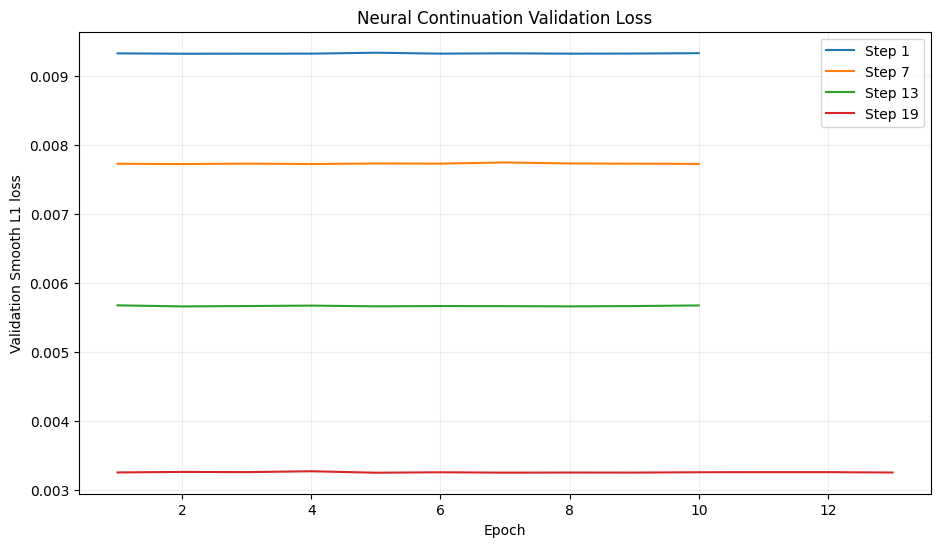

In [13]:
if not neural_training_history.empty:
    selected_steps = sorted(neural_training_history["step_index"].unique())
    selected_steps = selected_steps[:: max(len(selected_steps) // 4, 1)]
    plt.figure(figsize=(11, 6))
    for step_index in selected_steps:
        subset = neural_training_history[
            neural_training_history["step_index"] == step_index
        ]
        plt.plot(
            subset["epoch"],
            subset["validation_loss"],
            label=f"Step {step_index}",
        )
    plt.xlabel("Epoch")
    plt.ylabel("Validation Smooth L1 loss")
    plt.title("Neural Continuation Validation Loss")
    plt.legend()
    plt.grid(alpha=0.20)
    plt.show()

## 10. Held-out contract evaluation

For every held-out contract:

1. a CRR benchmark is calculated;
2. a classical policy is fitted on contract-specific training paths;
3. classical and neural policies are evaluated on the same independent valuation paths.

Using common valuation paths reduces noise in the policy comparison.

In [14]:
heldout_rows = []
heldout_policy_rows = []
runtime_rows = []
contract_valuation_cache = {}

for index, contract in enumerate(test_contracts):
    policy_paths = simulate_contract_paths(
        contract,
        n_paths=profile["policy_training_paths_per_contract"],
        n_steps=profile["exercise_steps"],
        seed=SEED + 3_000 + index,
    )
    valuation_paths = simulate_contract_paths(
        contract,
        n_paths=profile["valuation_paths_per_contract"],
        n_steps=profile["exercise_steps"],
        seed=SEED + 4_000 + index,
    )
    valuation_batch = ContractPathBatch(contract=contract, paths=valuation_paths)

    started = time.perf_counter()
    classical = longstaff_schwartz_put_price(
        policy_paths,
        valuation_paths,
        strike=contract.strike,
        time_to_maturity=contract.time_to_maturity,
        risk_free_rate=contract.risk_free_rate,
        basis=BEST_CLASSICAL_BASIS,
        degree=BEST_CLASSICAL_DEGREE,
    )
    classical_runtime = time.perf_counter() - started

    started = time.perf_counter()
    neural = evaluate_neural_lsm_policy(
        neural_policy,
        valuation_batch,
        device=DEVICE,
    )
    neural_runtime = time.perf_counter() - started

    started = time.perf_counter()
    crr_price = crr_option_price(
        spot=contract.spot,
        strike=contract.strike,
        time_to_maturity=contract.time_to_maturity,
        risk_free_rate=contract.risk_free_rate,
        dividend_yield=contract.dividend_yield,
        volatility=contract.volatility,
        steps=experiment_design["crr_benchmark_steps"],
        option_type="put",
        exercise_style="american",
    )
    crr_runtime = time.perf_counter() - started

    heldout_rows.append(
        {
            "contract_id": contract.contract_id,
            "crr_price": crr_price,
            "classical_lsm_price": classical.valuation.price,
            "classical_lsm_standard_error": classical.valuation.standard_error,
            "classical_lsm_ci_low": classical.valuation.confidence_interval_low,
            "classical_lsm_ci_high": classical.valuation.confidence_interval_high,
            "neural_lsm_price": neural.price,
            "neural_lsm_standard_error": neural.standard_error,
            "neural_lsm_ci_low": neural.confidence_interval_low,
            "neural_lsm_ci_high": neural.confidence_interval_high,
        }
    )
    policy_metrics = exercise_policy_metrics(
        classical.valuation.exercise_indices,
        neural.exercise_indices,
        maturity_index=profile["exercise_steps"],
    )
    policy_metrics["stopping_distribution_tv"] = stopping_time_total_variation(
        classical.valuation.exercise_indices,
        neural.exercise_indices,
        n_steps=profile["exercise_steps"],
    )
    heldout_policy_rows.append(
        {"contract_id": contract.contract_id, **policy_metrics}
    )
    runtime_rows.extend(
        [
            {"contract_id": contract.contract_id, "method": "CRR", "runtime_seconds": crr_runtime},
            {"contract_id": contract.contract_id, "method": "Classical LSM", "runtime_seconds": classical_runtime},
            {"contract_id": contract.contract_id, "method": "Neural LSM evaluation", "runtime_seconds": neural_runtime},
        ]
    )
    contract_valuation_cache[contract.contract_id] = {
        "classical": classical.valuation,
        "neural": neural,
    }

heldout_results = pd.DataFrame(heldout_rows)
print(heldout_results.head())

heldout_policy_metrics = pd.DataFrame(heldout_policy_rows)
runtime_records = pd.DataFrame(runtime_rows)

print("Held-out pricing rows:", len(heldout_results))
print("Policy metric rows:", len(heldout_policy_metrics))
print("Runtime rows:", len(runtime_records))

  contract_id  crr_price  classical_lsm_price  classical_lsm_standard_error  \
0   test_0000  23.218433            23.123257                  1.002778e-01   
1   test_0001  15.367097            15.322762                  7.681841e-02   
2   test_0002  16.099118            16.060834                  3.229325e-02   
3   test_0003  14.985948            14.984718                  4.766513e-17   
4   test_0004  11.800589            11.722244                  5.074232e-02   

   classical_lsm_ci_low  classical_lsm_ci_high  neural_lsm_price  \
0             22.926716              23.319798         23.070179   
1             15.172201              15.473324         15.303160   
2             15.997540              16.124128         16.007361   
3             14.984718              14.984718         14.984718   
4             11.622791              11.821697         11.724497   

   neural_lsm_standard_error  neural_lsm_ci_low  neural_lsm_ci_high  
0               9.888949e-02          22.87635

In [15]:
heldout_comparison = compare_lsm_methods(
    heldout_results,
    benchmark_column="crr_price",
    method_columns=["classical_lsm_price", "neural_lsm_price"],
)
heldout_comparison

,method,mae,rmse,median_absolute_error,maximum_absolute_error,mean_bias,normalized_mae
0,classical_lsm_price,0.039500,0.051623,0.031453,0.126719,-0.034377,0.004007
1,neural_lsm_price,0.087199,0.121772,0.063802,0.400425,-0.084350,0.006911


In [16]:
coverage_summary = pd.Series(
    {
        "Classical LSM 95% CI coverage": confidence_interval_coverage(
            heldout_results["crr_price"],
            heldout_results["classical_lsm_ci_low"],
            heldout_results["classical_lsm_ci_high"],
        ),
        "Neural LSM 95% CI coverage": confidence_interval_coverage(
            heldout_results["crr_price"],
            heldout_results["neural_lsm_ci_low"],
            heldout_results["neural_lsm_ci_high"],
        ),
    }
)
coverage_summary.to_frame("Coverage")

,Coverage
Classical LSM 95% CI coverage,0.88
Neural LSM 95% CI coverage,0.66


In [17]:
heldout_policy_metrics = pd.DataFrame(heldout_policy_rows)
heldout_policy_metrics.describe().T

,count,mean,std,min,25%,50%,75%,max
exact_step_agreement,100.0,0.657007,0.247171,0.00000,0.533705,0.69038,0.821725,1.00000
mean_absolute_step_error,100.0,1.408662,1.941888,0.00000,0.402625,0.80061,1.577070,12.73494
early_exercise_agreement,100.0,0.886954,0.171731,0.09674,0.891360,0.94164,0.969735,1.00000
false_early_exercise_rate,100.0,0.102951,0.173677,0.00000,0.017915,0.04743,0.102570,0.90326
missed_early_exercise_rate,100.0,0.010095,0.024496,0.00000,0.000595,0.00413,0.009090,0.21580
stopping_distribution_tv,100.0,0.270364,0.222237,0.00000,0.132750,0.22886,0.361325,1.00000


Pricing agreement and policy agreement answer different questions. Two policies can generate similar prices while exercising different paths at different dates. The stopping-time comparison therefore complements the contract-level pricing errors.

## 11. Out-of-domain evaluation

Out-of-domain contracts deliberately exceed the training ranges. The objective is not to expect perfect extrapolation, but to measure how quickly the neural stopping policy deteriorates relative to classical LSM.

In [18]:
ood_ranges = dict(in_domain_ranges)
ood_ranges["volatility"] = (0.70, 1.00)
ood_ranges["moneyness"] = (0.45, 1.55)
ood_contracts = sample_contracts_latin_hypercube(
    n_contracts=profile["ood_contracts"],
    parameter_ranges=ood_ranges,
    seed=SEED + 5_000,
    prefix="ood",
)

ood_rows = []
for index, contract in enumerate(ood_contracts):
    policy_paths = simulate_contract_paths(
        contract,
        n_paths=profile["policy_training_paths_per_contract"],
        n_steps=profile["exercise_steps"],
        seed=SEED + 6_000 + index,
    )
    valuation_paths = simulate_contract_paths(
        contract,
        n_paths=profile["valuation_paths_per_contract"],
        n_steps=profile["exercise_steps"],
        seed=SEED + 7_000 + index,
    )
    classical = longstaff_schwartz_put_price(
        policy_paths,
        valuation_paths,
        strike=contract.strike,
        time_to_maturity=contract.time_to_maturity,
        risk_free_rate=contract.risk_free_rate,
        basis=BEST_CLASSICAL_BASIS,
        degree=BEST_CLASSICAL_DEGREE,
    )
    neural = evaluate_neural_lsm_policy(
        neural_policy,
        ContractPathBatch(contract=contract, paths=valuation_paths),
        device=DEVICE,
    )
    crr_price = crr_option_price(
        spot=contract.spot,
        strike=contract.strike,
        time_to_maturity=contract.time_to_maturity,
        risk_free_rate=contract.risk_free_rate,
        dividend_yield=contract.dividend_yield,
        volatility=contract.volatility,
        steps=experiment_design["crr_benchmark_steps"],
        option_type="put",
        exercise_style="american",
    )
    ood_rows.append(
        {
            "contract_id": contract.contract_id,
            "crr_price": crr_price,
            "classical_lsm_price": classical.valuation.price,
            "neural_lsm_price": neural.price,
        }
    )

ood_results = pd.DataFrame(ood_rows)
ood_comparison = compare_lsm_methods(
    ood_results,
    benchmark_column="crr_price",
    method_columns=["classical_lsm_price", "neural_lsm_price"],
)
ood_comparison

,method,mae,rmse,median_absolute_error,maximum_absolute_error,mean_bias,normalized_mae
0,classical_lsm_price,0.066160,0.079402,0.061087,0.179158,-0.058386,0.002367
1,neural_lsm_price,0.946528,1.238234,0.682158,2.866541,-0.946528,0.026235


## 12. Multi-seed robustness

Monte Carlo conclusions should not depend on one random seed. The selected representative contract is repriced with multiple independent valuation samples. The neural policy remains fixed, while both policy noise and valuation noise are visible in the classical results.

In [19]:
robustness_rows = []
for seed in experiment_design["seeds"]:
    policy_paths = simulate_contract_paths(
        representative_contract,
        n_paths=profile["policy_training_paths_per_contract"],
        n_steps=profile["exercise_steps"],
        seed=seed + 8_000,
    )
    valuation_paths = simulate_contract_paths(
        representative_contract,
        n_paths=profile["valuation_paths_per_contract"],
        n_steps=profile["exercise_steps"],
        seed=seed + 9_000,
    )
    classical = longstaff_schwartz_put_price(
        policy_paths,
        valuation_paths,
        strike=representative_contract.strike,
        time_to_maturity=representative_contract.time_to_maturity,
        risk_free_rate=representative_contract.risk_free_rate,
        basis=BEST_CLASSICAL_BASIS,
        degree=BEST_CLASSICAL_DEGREE,
    )
    neural = evaluate_neural_lsm_policy(
        neural_policy,
        ContractPathBatch(
            contract=representative_contract,
            paths=valuation_paths,
        ),
        device=DEVICE,
    )
    robustness_rows.extend(
        [
            {
                "contract_id": representative_contract.contract_id,
                "seed": seed,
                "method": "classical_lsm",
                "price": classical.valuation.price,
            },
            {
                "contract_id": representative_contract.contract_id,
                "seed": seed,
                "method": "neural_lsm",
                "price": neural.price,
            },
        ]
    )

robustness_results = pd.DataFrame(robustness_rows)
aggregate_seed_results(robustness_results)

,index,contract_id,method,price_mean,price_std,seed_count
0,0,representative,classical_lsm,11.718117,0.023701,3
1,1,representative,neural_lsm,11.712886,0.036982,3


## 13. Runtime decomposition

The computational comparison separates:

- path simulation;
- classical policy fitting and valuation;
- neural policy training;
- marginal neural policy evaluation;
- CRR valuation.

This distinction matters because neural LSM has a high up-front policy-training cost but can reuse the policy across held-out contracts within the trained domain.

In [20]:
runtime_records = pd.DataFrame(runtime_rows)
runtime_table = runtime_summary(runtime_records)
runtime_table

,index,method,count,mean,median,min,max
0,0,CRR,100,0.091046,0.090855,0.090234,0.093470
1,1,Classical LSM,100,0.074467,0.082729,0.015076,0.099220
2,2,Neural LSM evaluation,100,0.070239,0.075390,0.008696,0.091959


In [21]:
runtime_context = pd.DataFrame(
    [
        {
            "method": "Neural LSM policy training",
            "runtime_seconds": neural_training_runtime,
            "frequency": "one-time per trained contract domain",
        },
        {
            "method": "Classical LSM",
            "runtime_seconds": runtime_records.loc[
                runtime_records["method"] == "Classical LSM",
                "runtime_seconds",
            ].mean(),
            "frequency": "repeated per contract",
        },
        {
            "method": "Neural LSM evaluation",
            "runtime_seconds": runtime_records.loc[
                runtime_records["method"] == "Neural LSM evaluation",
                "runtime_seconds",
            ].mean(),
            "frequency": "repeated per contract after policy training",
        },
    ]
)
runtime_context

,method,runtime_seconds,frequency
0,Neural LSM policy training,628.049543,one-time per trained contract domain
1,Classical LSM,0.074467,repeated per contract
2,Neural LSM evaluation,0.070239,repeated per contract after policy training


## 14. Link to the static surrogate models

The direct, premium, and multi-task networks from Notebooks 04–06 solve a different operational problem. They map contract parameters directly to prices and are expected to remain the fastest approach for large-scale repeated valuation.

This notebook saves its held-out contract grid and CRR benchmark values so Notebook 08 can apply all trained static surrogates to exactly the same contracts. That consolidated comparison avoids rebuilding earlier model-loading logic inside the LSM analysis.

## 15. Artifacts and reproducibility

The policy, contract grid, training history, classical and neural results, stopping-policy metrics, runtime summaries, and robustness outputs are persisted. Generated model artifacts remain excluded from Git, while the experiment configuration under `data/manifests/` is tracked.

In [22]:
def save_table(frame, path):
    """Save Parquet when available and fall back to CSV otherwise."""
    try:
        frame.to_parquet(path, index=False)
        return path
    except ImportError:
        fallback = path.with_suffix(".csv")
        frame.to_csv(fallback, index=False)
        return fallback


neural_policy.save(ARTIFACT_DIR / "neural_lsm_policy.pt")
saved_paths = [
    save_table(contract_grid, ARTIFACT_DIR / "contract_test_grid.parquet"),
    save_table(neural_training_history, ARTIFACT_DIR / "training_history.parquet"),
    save_table(basis_results, ARTIFACT_DIR / "classical_basis_results.parquet"),
    save_table(path_convergence, ARTIFACT_DIR / "path_convergence.parquet"),
    save_table(
        exercise_date_convergence,
        ARTIFACT_DIR / "exercise_date_convergence.parquet",
    ),
    save_table(heldout_results, ARTIFACT_DIR / "heldout_pricing_results.parquet"),
    save_table(
        heldout_policy_metrics,
        ARTIFACT_DIR / "heldout_policy_metrics.parquet",
    ),
    save_table(ood_results, ARTIFACT_DIR / "ood_results.parquet"),
    save_table(robustness_results, ARTIFACT_DIR / "robustness_results.parquet"),
    save_table(runtime_records, ARTIFACT_DIR / "runtime_records.parquet"),
]

summary = {
    "profile": PROFILE,
    "selected_classical_basis": BEST_CLASSICAL_BASIS,
    "selected_classical_degree": int(BEST_CLASSICAL_DEGREE),
    "neural_policy_steps": len(neural_policy.steps),
    "neural_training_runtime_seconds": neural_training_runtime,
    "heldout_comparison": heldout_comparison.to_dict(orient="records"),
    "ood_comparison": ood_comparison.to_dict(orient="records"),
    "coverage": coverage_summary.to_dict(),
    "saved_tables": [str(path) for path in saved_paths],
}
with (ARTIFACT_DIR / "evaluation_summary.json").open("w", encoding="utf-8") as file:
    json.dump(summary, file, indent=2)

print(f"Artifacts saved to: {ARTIFACT_DIR}")

Artifacts saved to: /storage/deep_learning_american_option_pricing/artifacts/neural_lsm


## 16. Interpretation framework

The final interpretation should distinguish four cases:

1. **Neural LSM improves both pricing and policy accuracy.**  
   This supports the hypothesis that nonlinear continuation regression adds value beyond fixed basis functions.

2. **Neural LSM improves pricing but not policy agreement.**  
   Similar aggregate values may conceal different stopping decisions.

3. **Neural LSM improves policy agreement but not price accuracy.**  
   Monte Carlo noise or continuation-value bias may offset the policy improvement.

4. **Classical LSM remains stronger.**  
   The added neural complexity would not be justified for this controlled one-dimensional problem.

No conclusion should be chosen before the final-profile results are produced.

## 17. Limitations

- Both classical and neural LSM use discretized exercise opportunities rather than continuous exercise.
- The neural policy is trained under geometric Brownian motion with constant parameters.
- Monte Carlo standard errors capture valuation-path uncertainty but not the full uncertainty of policy estimation.
- The neural policy can extrapolate poorly outside its contract domain.
- One continuation network per exercise index increases training and storage requirements.
- CRR and LSM discretization errors are different, so neither comparison is perfectly model-free.
- A strong result in this one-dimensional setting does not imply superiority for higher-dimensional derivatives.

## 18. References used in this notebook

Cox, J. C., Ross, S. A., & Rubinstein, M. (1979). Option pricing: A simplified approach. *Journal of Financial Economics, 7*(3), 229–263.

Longstaff, F. A., & Schwartz, E. S. (2001). Valuing American options by simulation: A simple least-squares approach. *Review of Financial Studies, 14*(1), 113–147.

Pu, V. R. H. (2021). *Pricing options using deep neural networks from a practical perspective: A comparative study of supervised and unsupervised learning* [Master's thesis, Imperial College London].

Zouaoui, H., & Naas, M.-N. (2023). Option pricing using deep learning approach based on LSTM-GRU neural networks. *Data Science in Finance and Economics, 3*(3), 267–284.

## 19. Development checkpoint

Step 7 is complete after the final profile has produced:

- validated GBM moments;
- classical basis, path-count, and exercise-date studies;
- a trained amortized neural stopping policy;
- held-out and out-of-domain pricing results;
- policy-agreement and stopping-time metrics;
- multi-seed robustness results;
- separated runtime costs.

Notebook 08 will consolidate all static and simulation-based models, decide the remaining hypotheses, and write the final project conclusions.